In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta

df_readiness = pd.read_csv('dailyreadiness_2024-08-01_2025-05-01.csv')
df_sleep = pd.read_csv('sleep_2024-08-01_2025-05-01.csv')
df_activity = pd.read_csv('dailyactivity_2024-08-01_2025-07-25.csv')
df_workout = pd.read_csv('workout_2024-08-01_2025-07-25.csv')
df_stress = pd.read_csv('dailystress_2024-08-01_2025-07-25.csv')

df_sleep = df_sleep.copy()

# keep long sleep only
df_sleep = df_sleep[df_sleep['type'] == 'long_sleep']

# parse day and compute hours
df_sleep['day'] = pd.to_datetime(df_sleep['day'], errors='coerce').dt.date
df_sleep['total_sleep_duration'] = pd.to_numeric(df_sleep['total_sleep_duration'], errors='coerce')

# seconds to hours
df_sleep['sleep_hours'] = df_sleep['total_sleep_duration'] / 3600.0

# Load ovulation/menstruation data
cycle_df = pd.read_csv('cleaned_weeklydata.csv', parse_dates=['ovulation_date', 'menzie_start', 'menzie_end'])

# Drop rows with missing participant ID or ovulation date
cycle_df = cycle_df.dropna(subset=['ovulation_date'])
cycle_df['name'] = cycle_df['id_num'].astype(int) # ensure consistency with df_merged

# Filter to participants with ≥3 ovulation dates
valid_participants = cycle_df.groupby('id_num')['ovulation_date'].count()
valid_participants = valid_participants[valid_participants >= 3].index
cycle_df = cycle_df[cycle_df['id_num'].isin(valid_participants)]

In [122]:
n_people = stress_phase['name'].nunique()
print("Unique participants:", n_people)

Unique participants: 267


In [123]:
# Print out the column names for each file

print("Daily Readiness columns:")
print(df_readiness.columns.tolist(), "\n")

print("Sleep columns:")
print(df_sleep.columns.tolist(), "\n")

print("Daily Activity columns:")
print(df_activity.columns.tolist(), "\n")

print("Workout columns:")
print(df_workout.columns.tolist(), "\n")

print("Daily Stress columns:")
print(df_stress.columns.tolist(), "\n")

print("Cycle/Weekly Data columns:")
print(cycle_df.columns.tolist(), "\n")

Daily Readiness columns:
['day', 'timestamp', 'contributors', 'score', 'temperature_deviation', 'temperature_trend_deviation', 'id', 'participant_id', 'name', 'email', 'group'] 

Sleep columns:
['day', 'type', 'total_sleep_duration', 'average_breath', 'average_heart_rate', 'average_hrv', 'awake_time', 'bedtime_end', 'bedtime_start', 'deep_sleep_duration', 'efficiency', 'heart_rate', 'hrv', 'latency', 'light_sleep_duration', 'low_battery_alert', 'lowest_heart_rate', 'movement_30_sec', 'period', 'readiness', 'readiness_score_delta', 'rem_sleep_duration', 'restless_periods', 'sleep_algorithm_version', 'sleep_phase_5_min', 'sleep_score_delta', 'time_in_bed', 'id', 'participant_id', 'name', 'email', 'group', 'sleep_hours'] 

Daily Activity columns:
['day', 'timestamp', 'active_calories', 'average_met_minutes', 'class_5_min', 'contributors', 'equivalent_walking_distance', 'high_activity_met_minutes', 'high_activity_time', 'inactivity_alerts', 'low_activity_met_minutes', 'low_activity_time', 

In [124]:
# Phase dictionaries to hold dates per participant
phase_dates = {}

cycle_df['menzie_start'] = pd.to_datetime(cycle_df['menzie_start'], errors='coerce')
cycle_df['menzie_end'] = pd.to_datetime(cycle_df['menzie_end'], errors='coerce')
cycle_df['ovulation_date'] = pd.to_datetime(cycle_df['ovulation_date'], errors='coerce')

# Iterate over participants
from datetime import timedelta

for pid in valid_participants:
    df_p = cycle_df[cycle_df['id_num'] == pid].sort_values('ovulation_date')
    menstrual = set()
    follicular = set()
    ovulation = set()
    luteal = set()

    for i in range(len(df_p)):
        row = df_p.iloc[i]
        
        ov_date = row['ovulation_date']
        men_start = row['menzie_start']
        men_end = row['menzie_end']

        # If no ovulation date, we really can't do anything
        if pd.isnull(ov_date):
            continue

        # Default: estimate 13 days luteal, 14 days follicular
        est_men_end = ov_date - timedelta(days=14)
        est_men_start = est_men_end - timedelta(days=3)

        # menstrual phase
        if pd.notnull(men_start) and pd.notnull(men_end):
            menstrual.update(pd.date_range(men_start, men_end))
        else:
            menstrual.update(pd.date_range(est_men_start, est_men_end))

        # follicular phase
        follic_start = (men_end + timedelta(days=1)) if pd.notnull(men_end) else (est_men_end + timedelta(days=1))
        follic_end = ov_date - timedelta(days=1)
        if follic_start <= follic_end:
            follicular.update(pd.date_range(follic_start, follic_end))

        # ovulation phase
        ovulation.add(ov_date)

        # luteal phase
        if i + 1 < len(df_p) and pd.notnull(df_p.iloc[i + 1]['menzie_start']):
            next_men_start = df_p.iloc[i + 1]['menzie_start']
        else:
            next_men_start = ov_date + timedelta(days=13)
        luteal_start = ov_date + timedelta(days=1)
        luteal_end = next_men_start - timedelta(days=1)
        if luteal_start <= luteal_end:
            luteal.update(pd.date_range(luteal_start, luteal_end))

    phase_dates[pid] = {
        'menstrual': menstrual,
        'follicular': follicular,
        'ovulation': ovulation,
        'luteal': luteal
    }

# Count how many phase dates were actually added
for pid, phases in phase_dates.items():
    print(f"Participant {pid} phase lengths:")
    for phase, dates in phases.items():
        print(f"  {phase}: {len(dates)}")

Participant 10205 phase lengths:
  menstrual: 11
  follicular: 29
  ovulation: 3
  luteal: 27
Participant 10211 phase lengths:
  menstrual: 12
  follicular: 36
  ovulation: 3
  luteal: 34
Participant 10228 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10229 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10262 phase lengths:
  menstrual: 10
  follicular: 28
  ovulation: 3
  luteal: 26
Participant 10268 phase lengths:
  menstrual: 12
  follicular: 31
  ovulation: 3
  luteal: 29
Participant 10269 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10277 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10280 phase lengths:
  menstrual: 10
  follicular: 28
  ovulation: 3
  luteal: 26
Participant 10304 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10323 phase lengths:
  menstrual: 12
  follicula

In [125]:
# Build a daily phase table
import pandas as pd
from itertools import chain

# phase_dates currently holds Timestamps - normalize to DATE and explode to rows
rows = []
for pid, phases in phase_dates.items():
    for ph, dates in phases.items():
        # ensure date-only (no time)
        for d in dates:
            d = pd.to_datetime(d).normalize().date()
            rows.append((int(pid), d, ph))

df_phase = pd.DataFrame(rows, columns=['name', 'day', 'phase']).drop_duplicates()

# Make sure 'day' is datetime64[ns] across all dataframes for merges
for df in [df_activity, df_readiness, df_sleep]:
    df['day'] = pd.to_datetime(df['day'], errors='coerce').dt.normalize()

df_phase['day'] = pd.to_datetime(df_phase['day']).dt.normalize()

# If 'name' column is not int already, standardize
for df in [df_activity, df_readiness, df_sleep]:
    # Some exports make 'name' strings - keep errors='ignore' (avoid breaking if already int)
    try:
        df['name'] = df['name'].astype(int)
    except Exception:
        pass

# Keep only participants that appear in both daily data and phase table
valid_ids = set(df_phase['name'].unique())
df_activity = df_activity[df_activity['name'].isin(valid_ids)]
df_readiness = df_readiness[df_readiness['name'].isin(valid_ids)]
df_sleep = df_sleep[df_sleep['name'].isin(valid_ids)]

In [126]:
# Join phase onto each daily file
# Left join = keep all daily rows - add phase when available
act_phase = df_activity.merge(df_phase, on=['name', 'day'], how='left')
ready_phase = df_readiness.merge(df_phase, on=['name', 'day'], how='left')
sleep_phase = df_sleep.merge(df_phase, on=['name', 'day'], how='left')

print("Counts by phase in activity:\n", act_phase['phase'].value_counts(dropna=False))
print("Counts by phase in readiness:\n", ready_phase['phase'].value_counts(dropna=False))
print("Counts by phase in sleep:\n", sleep_phase['phase'].value_counts(dropna=False))

Counts by phase in activity:
 phase
NaN           3942
follicular    1140
luteal        1072
menstrual      367
ovulation       94
Name: count, dtype: int64
Counts by phase in readiness:
 phase
NaN           1644
follicular    1039
luteal         802
menstrual      336
ovulation       73
Name: count, dtype: int64
Counts by phase in sleep:
 phase
NaN           1655
follicular    1042
luteal         809
menstrual      339
ovulation       73
Name: count, dtype: int64


resting_time: ANOVA F=1.205, p=0.30638  (n=2673)


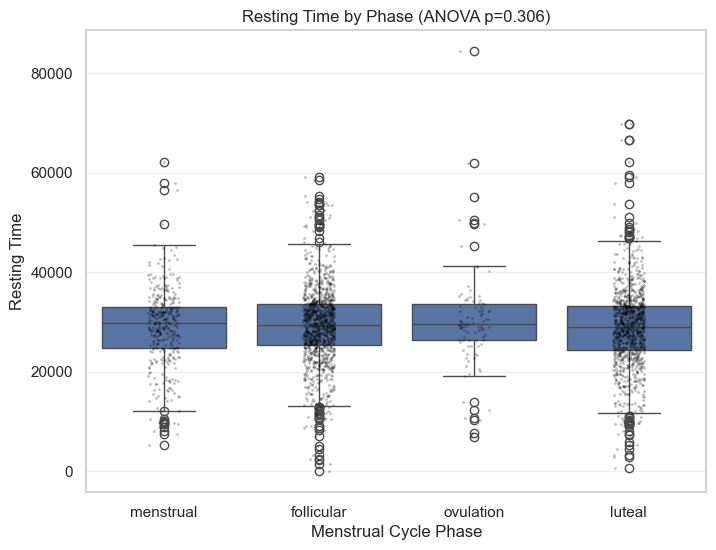

In [127]:
# resting_time vs phase
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

def boxplot_and_anova(df, ycol, title):
    dat = df.dropna(subset=['phase', ycol]).copy()
    dat = dat[dat['phase'].isin(['menstrual','follicular','ovulation','luteal'])]
    if dat['phase'].nunique() < 2:
        print(f"[{ycol}] Not enough phases to compare.")
        return
    groups = [g[ycol].values for _, g in dat.groupby('phase')]
    F, p = f_oneway(*groups)
    print(f"{ycol}: ANOVA F={F:.3f}, p={p:.5f}  (n={len(dat)})")
    plt.figure(figsize=(8,6))
    sns.boxplot(data=dat, x='phase', y=ycol, order=['menstrual','follicular','ovulation','luteal'])
    sns.stripplot(data=dat, x='phase', y=ycol, order=['menstrual','follicular','ovulation','luteal'],
                  color='black', alpha=0.25, jitter=True, size=2)
    plt.title(title + f" (ANOVA p={p:.3g})")
    plt.xlabel("Menstrual Cycle Phase")
    plt.ylabel(ycol.replace('_',' ').title())
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# Resting time
boxplot_and_anova(act_phase, 'resting_time', 'Resting Time by Phase')

score: ANOVA F=2.757, p=0.04096  (n=2615)


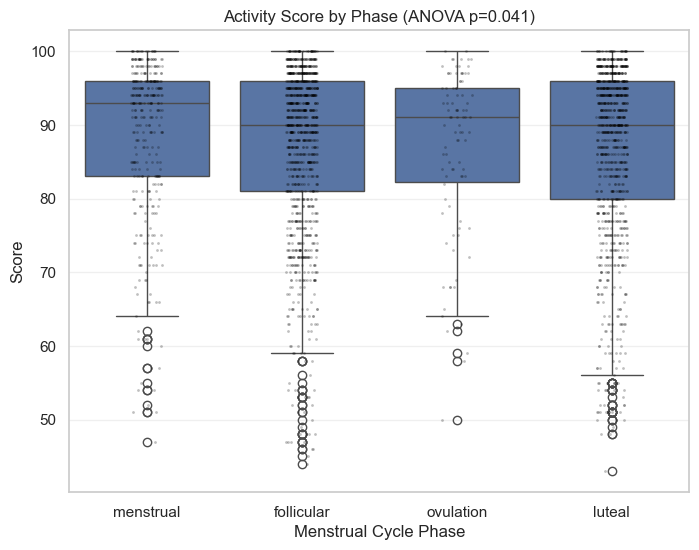

In [128]:
# activity_score vs phase
boxplot_and_anova(act_phase, 'score', 'Activity Score by Phase')

total_calories: ANOVA F=0.357, p=0.78404  (n=2673)


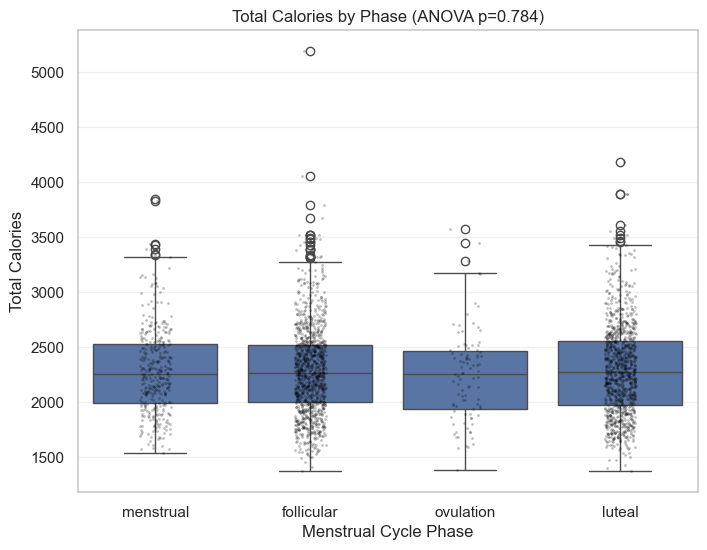

In [129]:
# Total calories vs phase
boxplot_and_anova(act_phase, 'total_calories', 'Total Calories by Phase')

stress_high: ANOVA F=13.478, p=0.00000  (n=2467)


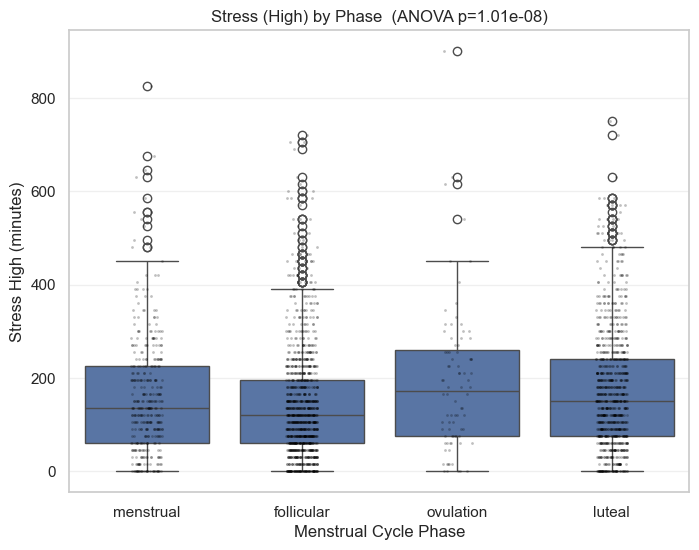

recovery_high: ANOVA F=20.957, p=0.00000  (n=2467)


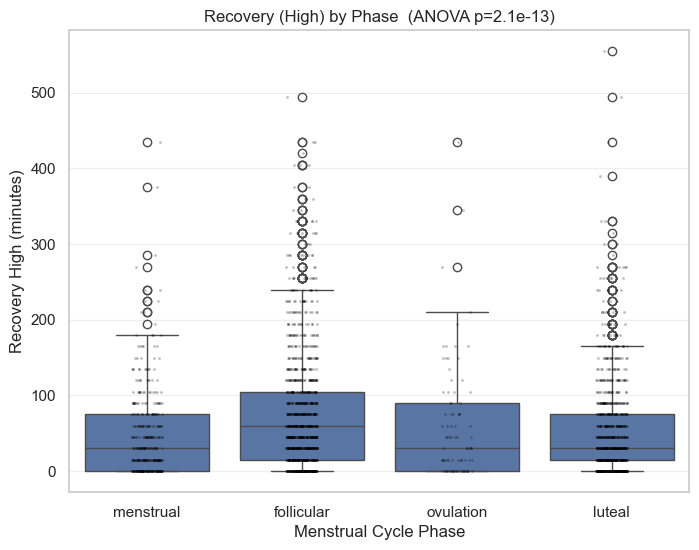

           stress_high                   recovery_high                 
                  mean         std count          mean        std count
phase                                                                  
follicular  140.718157  119.659720  1107     77.384824  80.737189  1107
luteal      173.644347  129.856644   911     55.718990  67.375886   911
menstrual   160.232877  129.925541   365     49.479452  60.279821   365
ovulation   191.071429  157.633232    84     62.142857  79.718200    84
stress_high: eta² = 0.016 (effect size)
recovery_high: eta² = 0.025 (effect size)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2  meandiff p-adj   lower    upper  reject
------------------------------------------------------------
follicular    luteal  32.9262    0.0  18.3835 47.4689   True
follicular menstrual  19.5147 0.0519  -0.1076 39.1371  False
follicular ovulation  50.3533 0.0025  13.5607 87.1458   True
    luteal menstrual -13.4115 0.3175 -33.5504  6

In [130]:
# Stress by phase

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import pandas as pd

# Normalize phase_dates to plain date objects
phase_dates_norm = {
    pid: {
        ph: { (d.date() if hasattr(d, "date") else d) for d in dates }
        for ph, dates in phases.items()
    }
    for pid, phases in phase_dates.items()
}

# Stress dataframe has proper types
df_stress = df_stress.copy()
df_stress['day'] = pd.to_datetime(df_stress['day'], errors='coerce').dt.date
for col in ['stress_high', 'recovery_high']:
    df_stress[col] = pd.to_numeric(df_stress[col], errors='coerce')

# seconds to minutes
df_stress['stress_high'] = df_stress['stress_high'] / 60.0
df_stress['recovery_high'] = df_stress['recovery_high'] / 60.0

# Attach phase to each stress row using phase_dates
def lookup_phase(row):
    phases_for_person = phase_dates_norm.get(row['name'], {})
    # return the first phase whose date set contains this day
    for ph, dates in phases_for_person.items():
        if row['day'] in dates:
            return ph
    return np.nan

stress_phase = df_stress.copy()
stress_phase['phase'] = stress_phase.apply(lookup_phase, axis=1)

# Helper boxplot and one way ANOVA
def boxplot_and_anova(df, ycol, title):
    dat = df.dropna(subset=['phase', ycol]).copy()
    # keep standard phase order only
    order = ['menstrual', 'follicular', 'ovulation', 'luteal']
    dat = dat[dat['phase'].isin(order)]
    if dat['phase'].nunique() < 2:
        print(f"[{ycol}] Not enough phases to compare (n={len(dat)}).")
        return

    # ANOVA
    groups = [g[ycol].values for _, g in dat.groupby('phase')]
    F, p = f_oneway(*groups)
    print(f"{ycol}: ANOVA F={F:.3f}, p={p:.5f}  (n={len(dat)})")

    # Plot
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=dat, x='phase', y=ycol, order=order)
    sns.stripplot(data=dat, x='phase', y=ycol, order=order,
                  color='black', alpha=0.25, jitter=True, size=2)
    # 🔹 Update y-axis label to minutes
    plt.title(f"{title}  (ANOVA p={p:.3g})")
    plt.xlabel("Menstrual Cycle Phase")
    plt.ylabel(ycol.replace('_', ' ').title() + " (minutes)")
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# Plots
boxplot_and_anova(stress_phase, 'stress_high',   'Stress (High) by Phase')
boxplot_and_anova(stress_phase, 'recovery_high', 'Recovery (High) by Phase')

# Group means and std dev
summary = stress_phase.groupby('phase')[['stress_high', 'recovery_high']].agg(['mean', 'std', 'count'])
print(summary)

def anova_eta_squared(df, ycol):
    dat = df.dropna(subset=['phase', ycol]).copy()
    groups = [g[ycol].values for _, g in dat.groupby('phase')]
    F, p = f_oneway(*groups)

    # total sum of squares
    grand_mean = dat[ycol].mean()
    ss_total = ((dat[ycol] - grand_mean)**2).sum()

    # between group sum of squares
    ss_between = sum([len(g) * (g.mean() - grand_mean)**2 for g in groups])

    eta_sq = ss_between / ss_total
    print(f"{ycol}: eta² = {eta_sq:.3f} (effect size)")
    return eta_sq

anova_eta_squared(stress_phase, 'stress_high')
anova_eta_squared(stress_phase, 'recovery_high')

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Build a clean, aligned subset once
dat = stress_phase[['phase','stress_high']].copy()
dat = dat.dropna(subset=['phase','stress_high'])
dat = dat[dat['phase'].isin(['menstrual','follicular','ovulation','luteal'])]

# Tukey for stress_high
tukey_stress = pairwise_tukeyhsd(
    endog=dat['stress_high'].values,
    groups=dat['phase'].values,
    alpha=0.05
)
print(tukey_stress)

# Repeat for recovery_high
dat2 = stress_phase[['phase','recovery_high']].copy()
dat2 = dat2.dropna(subset=['phase','recovery_high'])
dat2 = dat2[dat2['phase'].isin(['menstrual','follicular','ovulation','luteal'])]

tukey_recovery = pairwise_tukeyhsd(
    endog=dat2['recovery_high'].values,
    groups=dat2['phase'].values,
    alpha=0.05
)
print(tukey_recovery)

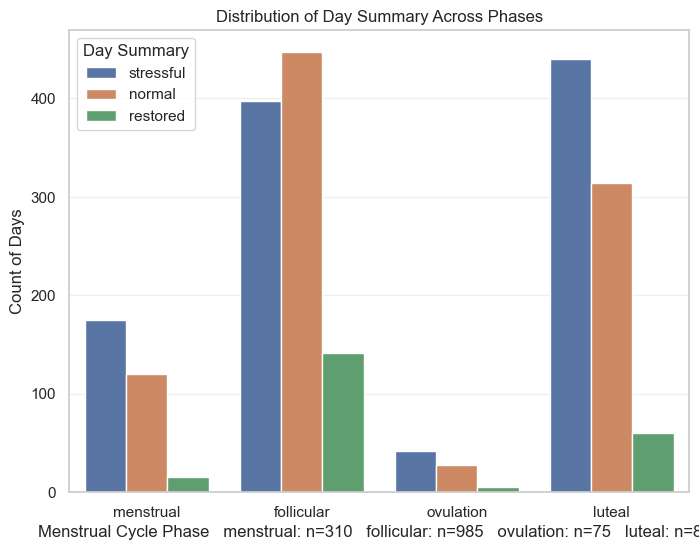

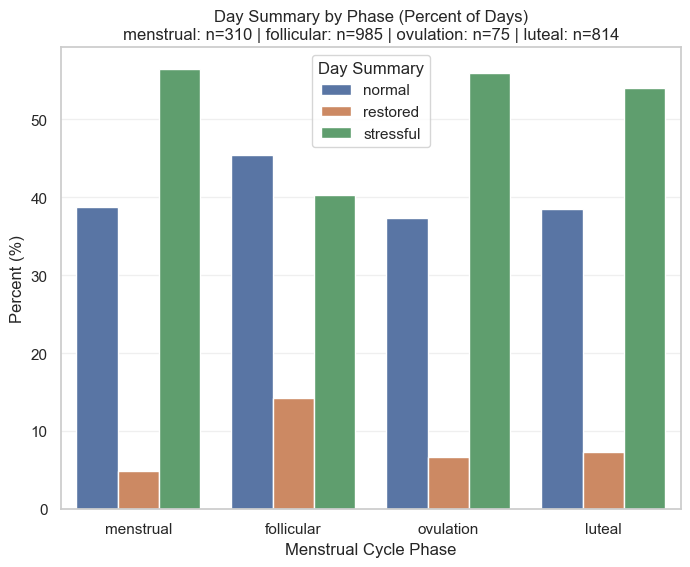

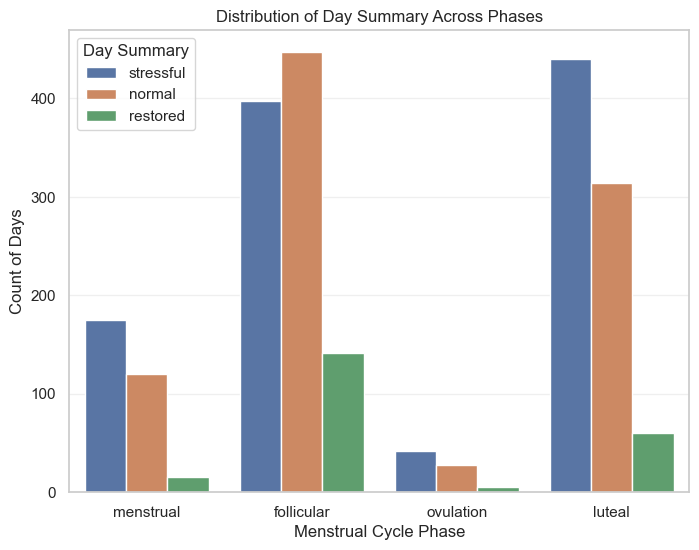

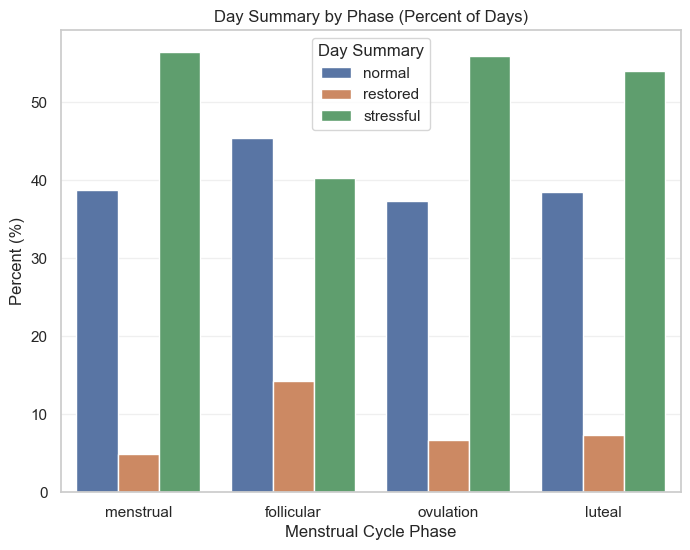

In [131]:

# day_summary vs phase

import seaborn as sns
import matplotlib.pyplot as plt

# Count raw distribution across phases
order = ['menstrual','follicular','ovulation','luteal']
dat = stress_phase.dropna(subset=['phase','day_summary'])
dat = dat[dat['phase'].isin(order)]

# helper to annotate bars with n
def annotate_counts(ax, totals):
    for p in ax.patches:
        # bar's x position - phase label
        phase = p.get_x() + p.get_width()/2
        height = p.get_height()
        ax.text(phase, height, '', ha='center', va='bottom', fontsize=0.1)  # keep layout stable
    # put "n=" line under the x-axis labels
    labs = [t.get_text() for t in ax.get_xticklabels()]
    ns = [int(totals.get(ph, 0)) for ph in labs]
    ax.set_xlabel(ax.get_xlabel() + "   " + "   ".join([f"{ph}: n={n}" for ph, n in zip(labs, ns)]))

# raw counts with n per phase
phase_totals = dat.groupby('phase').size().reindex(order, fill_value=0).to_dict()

plt.figure(figsize=(8,6))
ax = sns.countplot(data=dat, x='phase', hue='day_summary', order=order)
plt.title("Distribution of Day Summary Across Phases")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Count of Days")
plt.legend(title="Day Summary")
plt.grid(True, axis='y', alpha=0.3)
annotate_counts(ax, phase_totals)
plt.show()

# % within phase with n per phase in the subtitle
counts = (
    dat.groupby(['phase', 'day_summary'])
       .size().reset_index(name='n')
)
counts['percent'] = counts['n'] / counts.groupby('phase')['n'].transform('sum') * 100

plt.figure(figsize=(8,6))
ax = sns.barplot(data=counts, x='phase', y='percent', hue='day_summary', order=order)
n_line = " | ".join([f"{ph}: n={phase_totals.get(ph,0)}" for ph in order])
plt.title(f"Day Summary by Phase (Percent of Days)\n{n_line}")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Percent (%)")
plt.legend(title="Day Summary")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
sns.countplot(data=dat, x='phase', hue='day_summary', order=order)
plt.title("Distribution of Day Summary Across Phases")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Count of Days")
plt.legend(title="Day Summary")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Proportional bars (percent within each phase)
dat = stress_phase.dropna(subset=['phase', 'day_summary']).copy()
dat = dat[dat['phase'].isin(order)]

# Counts by phase x day_summary
counts = (
    dat.groupby(['phase', 'day_summary'])
       .size()
       .reset_index(name='n')
)

# Percent within phase
counts['percent'] = counts['n'] / counts.groupby('phase')['n'].transform('sum') * 100

plt.figure(figsize=(8,6))
sns.barplot(data=counts, x='phase', y='percent', hue='day_summary', order=order)
plt.title("Day Summary by Phase (Percent of Days)")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Percent (%)")
plt.legend(title="Day Summary")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

    name       phase day_summary   n    percent
0  10205  follicular      normal   8  44.444444
1  10205  follicular    restored   3  16.666667
2  10205  follicular   stressful   7  38.888889
3  10205      luteal      normal   5  27.777778
4  10205      luteal   stressful  13  72.222222


/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/2411614828.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


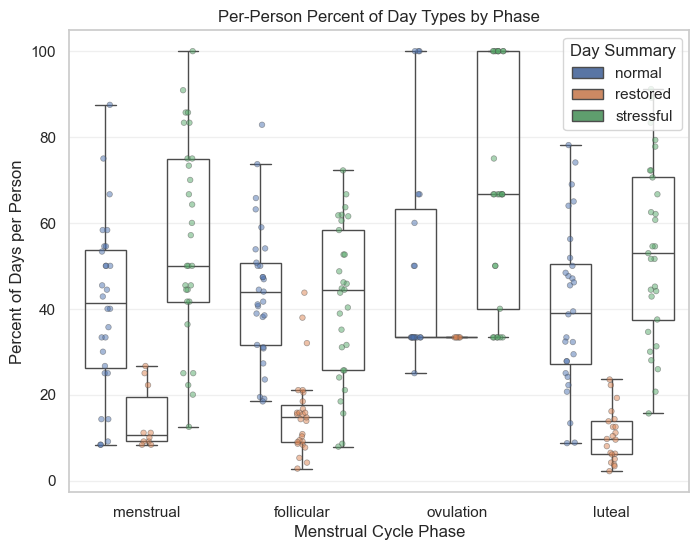

In [132]:
# Per-person percentage breakdown
person_phase_summary = (
    dat.groupby(['name', 'phase', 'day_summary'])
       .size()
       .reset_index(name='n')
)

# Normalize within each (person, phase)
person_phase_summary['percent'] = (
    person_phase_summary['n'] /
    person_phase_summary.groupby(['name','phase'])['n'].transform('sum') * 100
)

print(person_phase_summary.head())

plt.figure(figsize=(8,6))

# Boxplot (summary across people)
sns.boxplot(
    data=person_phase_summary,
    x='phase', y='percent', hue='day_summary',
    order=order, dodge=True, showcaps=True,
    boxprops={'facecolor':'None'},  # transparent boxes
    showfliers=False  # hide outliers since stripplot will show them
)

# Stripplot (individual data points)
sns.stripplot(
    data=person_phase_summary,
    x='phase', y='percent', hue='day_summary',
    order=order, dodge=True, jitter=True,
    alpha=0.5, size=4, linewidth=0.5, edgecolor='gray'
)

plt.title("Per-Person Percent of Day Types by Phase")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Percent of Days per Person")

# Fix legend (boxplot and stripplot added duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:3], labels[0:3], title="Day Summary")

plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [133]:
from scipy.stats import ttest_ind

# ex. stressful days % menstrual vs follicular
stressful = person_phase_summary[
    (person_phase_summary['day_summary']=='stressful')
]

results = []
for pid, dfp in stressful.groupby('name'):
    if set(dfp['phase']) >= {'menstrual','follicular'}:
        m = dfp.loc[dfp['phase']=='menstrual', 'percent']
        f = dfp.loc[dfp['phase']=='follicular', 'percent']
        if not m.empty and not f.empty:
            t, p = ttest_ind(m, f, equal_var=False)
            results.append({'name': pid, 't': t, 'p': p})

pd.DataFrame(results).head()

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/315957540.py:14: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t, p = ttest_ind(m, f, equal_var=False)
/opt/anaconda3/envs/dailyreadinessvsleep/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/opt/anaconda3/envs/dailyreadinessvsleep/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


,name,t,p
0,10205,NaN,NaN
1,10211,NaN,NaN
2,10228,NaN,NaN
3,10229,NaN,NaN
4,10262,NaN,NaN


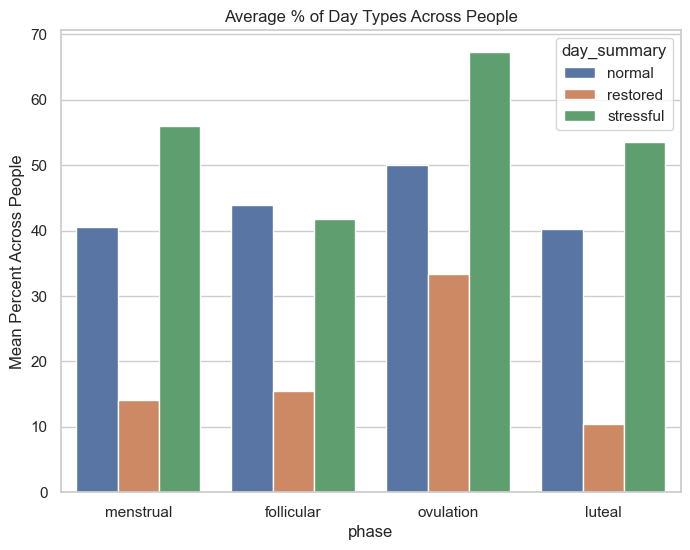

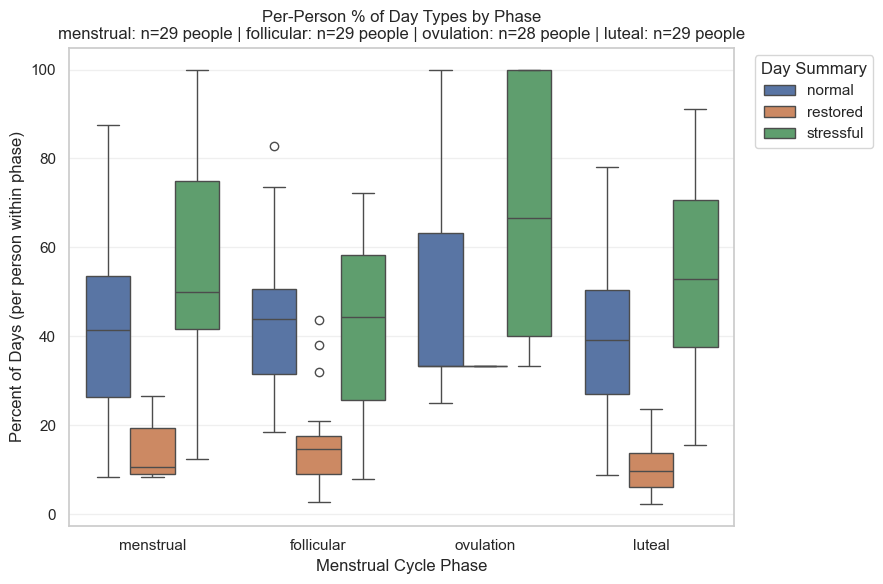

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/1973294258.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


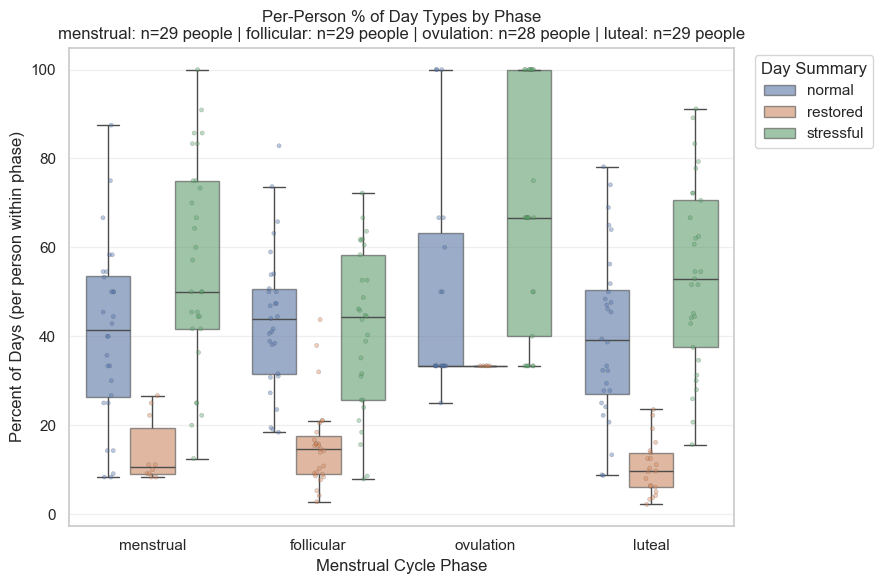

In [134]:
# Average % across people per phase
avg_percentages = (
    person_phase_summary.groupby(['phase','day_summary'])['percent']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=avg_percentages, x='phase', y='percent', hue='day_summary',
            order=order)
plt.title("Average % of Day Types Across People")
plt.ylabel("Mean Percent Across People")
plt.show()

# Count participants contributing to each phase (for label)
n_participants_per_phase = (
    person_phase_summary.groupby('phase')['name'].nunique()
    .reindex(order, fill_value=0).to_dict()
)

plt.figure(figsize=(9,6))
ax = sns.boxplot(
    data=person_phase_summary,
    x='phase', y='percent', hue='day_summary',
    order=order, showfliers=True
)

n_line = " | ".join([f"{ph}: n={n_participants_per_phase.get(ph,0)} people" for ph in order])
plt.title(f"Per-Person % of Day Types by Phase\n{n_line}")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Percent of Days (per person within phase)")
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title="Day Summary", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))

# Boxplot
sns.boxplot(
    data=person_phase_summary,
    x='phase', y='percent', hue='day_summary',
    order=order, showfliers=False,  # hide fliers so stripplot handles outliers
    boxprops={'alpha':0.6}
)

# Stripplot overlay
sns.stripplot(
    data=person_phase_summary,
    x='phase', y='percent', hue='day_summary',
    order=order, dodge=True, jitter=True,
    alpha=0.4, size=3, linewidth=0.3, edgecolor='gray'
)

# Fix legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:len(set(person_phase_summary['day_summary']))], 
           labels[0:len(set(person_phase_summary['day_summary']))],
           title="Day Summary", bbox_to_anchor=(1.02, 1), loc='upper left')


n_line = " | ".join([f"{ph}: n={n_participants_per_phase.get(ph,0)} people" for ph in order])
plt.title(f"Per-Person % of Day Types by Phase\n{n_line}")

plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Percent of Days (per person within phase)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

calories: ANOVA F=0.498, p=0.68378  (n=339)


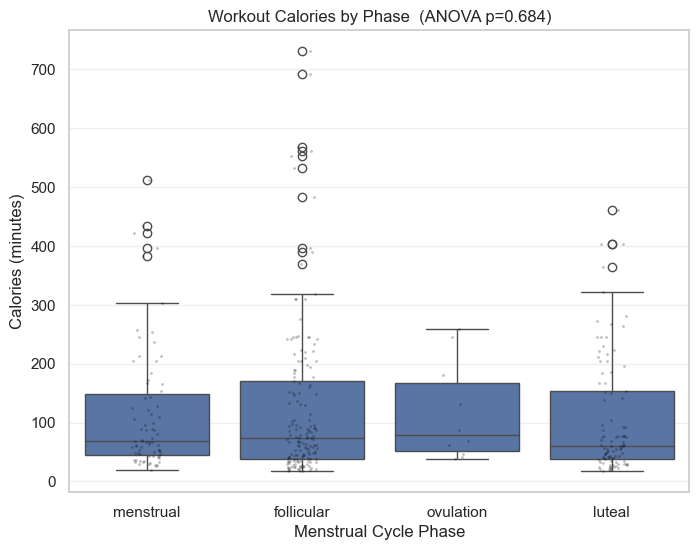

In [135]:

# calories vs phase

# Map workout rows to phase (uses existing `phase_dates`)
df_workout['day'] = pd.to_datetime(df_workout['day'], errors='coerce')

workout_phase = df_workout.copy()
workout_phase['phase'] = workout_phase.apply(
    lambda row: next(
        (ph for ph, dates in phase_dates.get(row['name'], {}).items()
         if row['day'].normalize() in dates or row['day'].date() in dates),
        np.nan
    ),
    axis=1
)

# Box/strip and ANOVA
boxplot_and_anova(workout_phase, 'calories', 'Workout Calories by Phase')

In [136]:
# Build merged dataframe "wide"
# Make sure all days are datetime.date
df_sleep['day'] = pd.to_datetime(df_sleep['day'], errors='coerce').dt.date
df_activity['day'] = pd.to_datetime(df_activity['day'], errors='coerce').dt.date
df_stress['day'] = pd.to_datetime(df_stress['day'], errors='coerce').dt.date
df_workout['day'] = pd.to_datetime(df_workout['day'], errors='coerce').dt.date

# Normalize sleep to hours
df_sleep['sleep_hours'] = df_sleep['total_sleep_duration'] / 3600

df_sleep = df_sleep[df_sleep['type'] == 'long_sleep'].copy()

# Aggregate workouts per day (so they line up with sleep/activity/stress)
workout_daily = (
    df_workout.groupby(['name','day'])
    .agg({'calories':'sum', 'distance':'sum'})
    .reset_index()
    .rename(columns={'calories':'workout_calories', 'distance':'workout_distance'})
)

# Merge everything
wide = df_sleep[['name','day','sleep_hours']].merge(
    df_activity[['name','day','total_calories','score','resting_time']],
    on=['name','day'], how='outer'
).merge(
    df_stress[['name','day','stress_high','recovery_high','day_summary']],
    on=['name','day'], how='outer'
).merge(
    workout_daily,
    on=['name','day'], how='outer'
)

# Attach phase
def lookup_phase(row):
    phases_for_person = phase_dates.get(row['name'], {})
    for ph, dates in phases_for_person.items():
        if row['day'] in { (d.date() if hasattr(d,"date") else d) for d in dates }:
            return ph
    return None

wide['phase'] = wide.apply(lookup_phase, axis=1)

print("wide columns:", wide.columns.tolist())
print("Rows with phases:", wide['phase'].notna().sum())

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/3943266875.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sleep['day'] = pd.to_datetime(df_sleep['day'], errors='coerce').dt.date
/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/3943266875.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sleep['sleep_hours'] = df_sleep['total_sleep_duration'] / 3600


wide columns: ['name', 'day', 'sleep_hours', 'total_calories', 'score', 'resting_time', 'stress_high', 'recovery_high', 'day_summary', 'workout_calories', 'workout_distance', 'phase']
Rows with phases: 2789


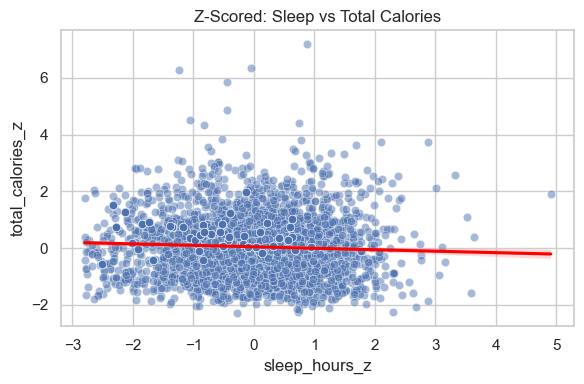

Z-Scored: Sleep vs Total Calories: r = -0.052, p = 0.00105, n = 4008


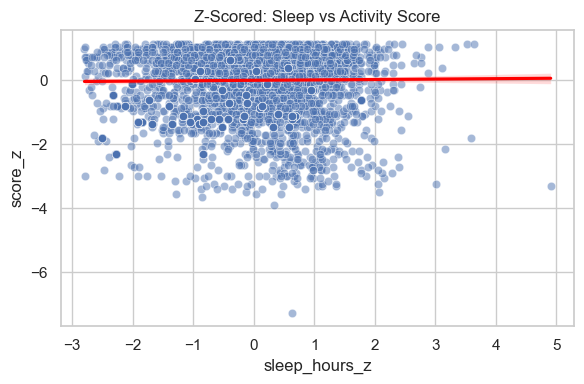

Z-Scored: Sleep vs Activity Score: r = 0.013, p = 0.422, n = 3921


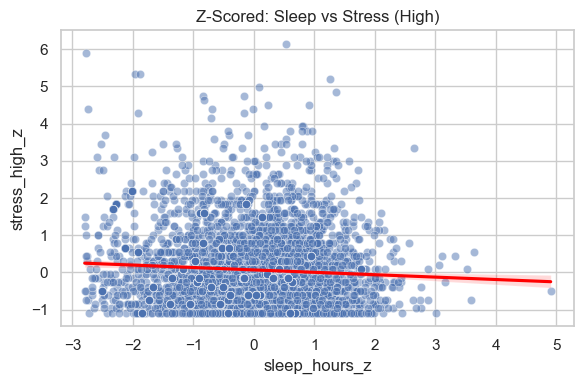

Z-Scored: Sleep vs Stress (High): r = -0.065, p = 3.89e-05, n = 3984


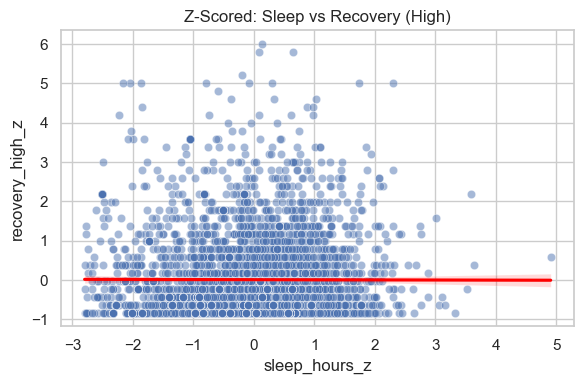

Z-Scored: Sleep vs Recovery (High): r = -0.003, p = 0.853, n = 3984


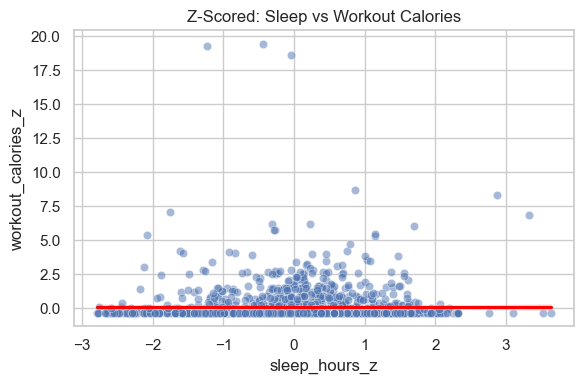

Z-Scored: Sleep vs Workout Calories: r = 0.000, p = 0.997, n = 1728


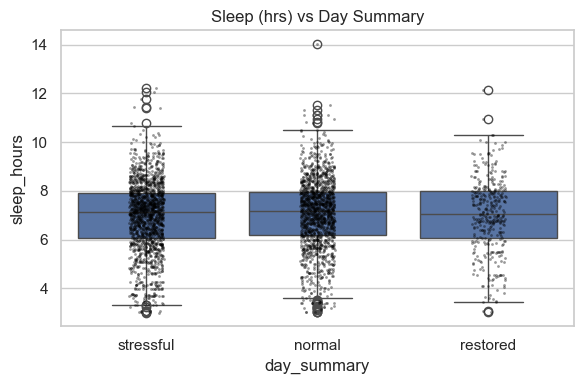


ANOVA: sleep_hours ~ day_summary
                     sum_sq      df       F    PR(>F)
C(day_summary)     7.210435     2.0  1.7297  0.177493
Residual        7130.399634  3421.0     NaN       NaN


In [137]:
# Z-scored sleep vs other variables and categorical test
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols

# scatter and Pearson r helper
def scatter_and_corr(df, x, y, title):
    d = df[[x, y]].dropna()
    if d.empty:
        print(f"No data for {title}")
        return
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=d, x=x, y=y, alpha=0.5)
    sns.regplot(data=d, x=x, y=y, scatter=False, color='red')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    r, p = pearsonr(d[x], d[y])
    print(f"{title}: r = {r:.3f}, p = {p:.3g}, n = {len(d)}")

# z-scored columns (avoids index alignment issues)
cont_cols = ['sleep_hours', 'total_calories', 'score', 'stress_high', 'recovery_high', 'workout_calories']
for col in cont_cols:
    if col in wide.columns:
        mu = wide[col].mean(skipna=True)
        sd = wide[col].std(skipna=True)
        wide[col + '_z'] = (wide[col] - mu) / sd

# Standardized correlations/plots 
scatter_and_corr(wide, 'sleep_hours_z', 'total_calories_z', "Z-Scored: Sleep vs Total Calories")
scatter_and_corr(wide, 'sleep_hours_z', 'score_z',            "Z-Scored: Sleep vs Activity Score")
scatter_and_corr(wide, 'sleep_hours_z', 'stress_high_z',      "Z-Scored: Sleep vs Stress (High)")
scatter_and_corr(wide, 'sleep_hours_z', 'recovery_high_z',    "Z-Scored: Sleep vs Recovery (High)")
scatter_and_corr(wide, 'sleep_hours_z', 'workout_calories_z', "Z-Scored: Sleep vs Workout Calories")

# Sleep vs categorical (day_summary)
# Use raw sleep_hours so units are interpretable (hours)
if 'day_summary' in wide.columns:
    d_cat = wide[['sleep_hours','day_summary']].dropna()
    if not d_cat.empty:
        plt.figure(figsize=(6,4))
        sns.boxplot(data=d_cat, x='day_summary', y='sleep_hours')
        sns.stripplot(data=d_cat, x='day_summary', y='sleep_hours',
                      color='black', alpha=0.4, jitter=True, size=2)
        plt.title("Sleep (hrs) vs Day Summary")
        plt.tight_layout()
        plt.show()

        # One-way ANOVA
        model = ols('sleep_hours ~ C(day_summary)', data=d_cat).fit()
        print("\nANOVA: sleep_hours ~ day_summary")
        print(sm.stats.anova_lm(model, typ=2))
    else:
        print("No data for Sleep vs Day Summary (after dropping NaNs).")
else:
    print("Column 'day_summary' not found in 'wide'.")

In [138]:
# find r squared
def scatter_and_corr(df, x, y, title):
    d = df[[x, y]].dropna()
    if d.empty:
        print(f"No data for {title}")
        return
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=d, x=x, y=y, alpha=0.5)
    sns.regplot(data=d, x=x, y=y, scatter=False, color='red')
    plt.title(title)
    plt.show()
    
    r, p = pearsonr(d[x], d[y])
    r2 = r**2
    print(f"{title}: r = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}, n = {len(d)}")

# simple regression
import statsmodels.api as sm

def regression_summary(df, x, y):
    d = df[[x, y]].dropna()
    X = sm.add_constant(d[x])
    model = sm.OLS(d[y], X).fit()
    print(model.summary())

regression_summary(wide, 'sleep_hours_z', 'total_calories_z')
regression_summary(wide, 'sleep_hours_z', 'stress_high_z')

                            OLS Regression Results                            
Dep. Variable:       total_calories_z   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     10.76
Date:                Mon, 01 Sep 2025   Prob (F-statistic):            0.00105
Time:                        23:46:43   Log-Likelihood:                -5666.7
No. Observations:                4008   AIC:                         1.134e+04
Df Residuals:                    4006   BIC:                         1.135e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0501      0.016      3.189

In [139]:
# only if columns NOT already in wide
# df_workout must have correct dtypes
df_workout = df_workout.copy()
df_workout['day'] = pd.to_datetime(df_workout['day'], errors='coerce')
df_workout['distance'] = pd.to_numeric(df_workout['distance'], errors='coerce')
df_workout['calories'] = pd.to_numeric(df_workout['calories'], errors='coerce')

# daily totals per person-day from workouts
w_agg = (df_workout
         .groupby(['name','day'])
         .agg(workout_distance=('distance','sum'),
              workout_calories=('calories','sum'))
         .reset_index())

# "main activity" of the day = most frequent activity label that day (mode)
mode_act = (df_workout
            .dropna(subset=['activity'])
            .groupby(['name','day'])['activity']
            .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            .reset_index()
            .rename(columns={'activity':'main_activity'}))

w_agg = w_agg.merge(mode_act, on=['name','day'], how='left')

# attach to `wide` (keys must be same dtype)
wide = wide.copy()
wide['day'] = pd.to_datetime(wide['day'], errors='coerce')
wide = wide.merge(w_agg, on=['name','day'], how='left')

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

def scatter_and_corr(df, x, y, title):
    d = df[[x, y]].apply(pd.to_numeric, errors='coerce').dropna()
    if d.empty:
        print(f"No data for {title}")
        return
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=d, x=x, y=y, alpha=0.5)
    sns.regplot(data=d, x=x, y=y, scatter=False, color='red')
    plt.title(title)
    plt.xlabel(x.replace('_',' ').title())
    plt.ylabel(y.replace('_',' ').title())
    plt.tight_layout()
    plt.show()
    r, p = pearsonr(d[x], d[y])
    print(f"{title}: r = {r:.3f}, p = {p:.3g}, n = {len(d)}")

def boxplot_and_anova(df, x_cat, y_cont, title, order=None):
    d = df[[x_cat, y_cont]].copy()
    d[y_cont] = pd.to_numeric(d[y_cont], errors='coerce')
    d = d.dropna()
    if d.empty or d[x_cat].nunique() < 2:
        print(f"Not enough data for {title}")
        return
    plt.figure(figsize=(7,5))
    sns.boxplot(data=d, x=x_cat, y=y_cont, order=order)
    sns.stripplot(data=d, x=x_cat, y=y_cont, order=order,
                  color='black', alpha=0.3, jitter=True, size=2)
    plt.title(title)
    plt.xlabel(x_cat.replace('_',' ').title())
    plt.ylabel(y_cont.replace('_',' ').title())
    plt.tight_layout()
    plt.show()

    # one-way ANOVA across categories (balanced or not)
    groups = [g[y_cont].values for _, g in d.groupby(x_cat)]
    F, p = f_oneway(*groups)
    print(f"{title} — ANOVA: F = {F:.3f}, p = {p:.3g}, k = {d[x_cat].nunique()}, n = {len(d)}")

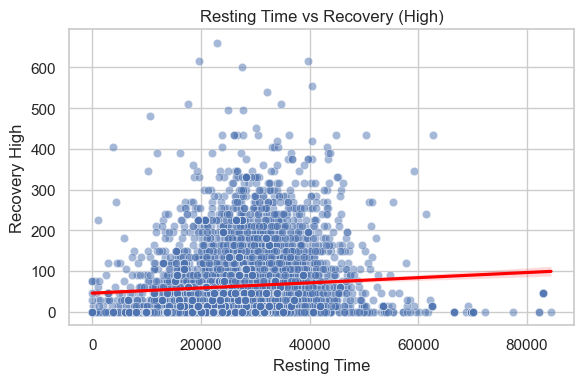

Resting Time vs Recovery (High): r = 0.073, p = 2.12e-09, n = 6766


In [141]:
# resting_time vs recovery_high
scatter_and_corr(wide, 'resting_time', 'recovery_high',
                 "Resting Time vs Recovery (High)")

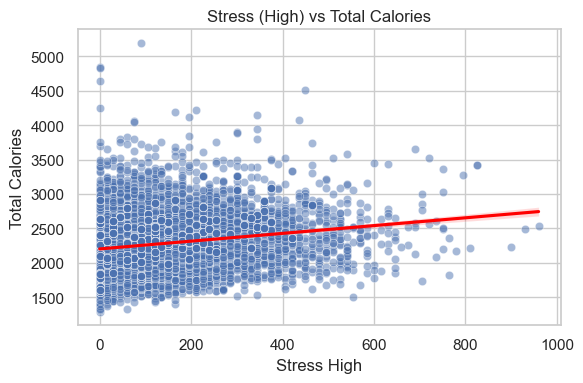

Stress (High) vs Total Calories: r = 0.184, p = 1.74e-52, n = 6766


In [142]:
#stress_high vs total_calories
scatter_and_corr(wide, 'stress_high', 'total_calories',
                 "Stress (High) vs Total Calories")

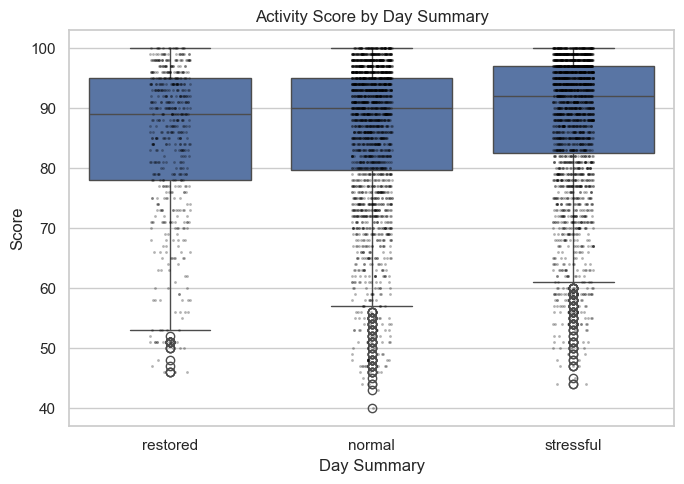

Activity Score by Day Summary — ANOVA: F = 25.751, p = 7.36e-12, k = 3, n = 5665


In [143]:
# score vs day_summary
# If activity score lives in wide['score'] but collides with readiness score,
# wide = wide.rename(columns={'score':'activity_score'})
boxplot_and_anova(wide, x_cat='day_summary', y_cont='score',
                  title="Activity Score by Day Summary",
                  order=['restored','normal','stressful'])

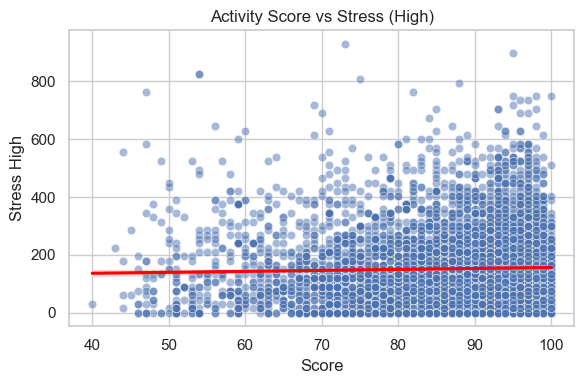

Activity Score vs Stress (High): r = 0.030, p = 0.0144, n = 6527


In [144]:
# score vs stress_high
scatter_and_corr(wide, 'score', 'stress_high',
                 "Activity Score vs Stress (High)")

In [145]:
# keys aligned earlier
wide['day'] = pd.to_datetime(wide['day'], errors='coerce').dt.date
df_activity['day'] = pd.to_datetime(df_activity['day'], errors='coerce').dt.date
wide['name'] = wide['name'].astype('Int64')
df_activity['name'] = df_activity['name'].astype('Int64')

# Keep/rename activity cols
act_keep = ['day', 'name', 'high_activity_time', 'total_calories', 'score']
activity_small = (
    df_activity[act_keep]
      .rename(columns={'score': 'activity_score'})
    # collapse to one row per (day,name) if needed
      .groupby(['day','name'], as_index=False)
      .agg({'high_activity_time':'sum', 'total_calories':'sum', 'activity_score':'mean'})
)

# Merge FIRST (allowing suffixes)
wide = wide.merge(activity_small, on=['day','name'], how='left', suffixes=('', '_act'))

# If new cols were suffixed, standardize names
for col in ['high_activity_time', 'total_calories', 'activity_score']:
    alt = f'{col}_act'
    if col not in wide.columns and alt in wide.columns:
        wide.rename(columns={alt: col}, inplace=True)

# convert to numeric
for col in ['high_activity_time', 'total_calories', 'activity_score']:
    if col in wide.columns:
        wide[col] = pd.to_numeric(wide[col], errors='coerce')

# sanity check
#print(wide[['day','name','high_activity_time','total_calories','activity_score']].head())

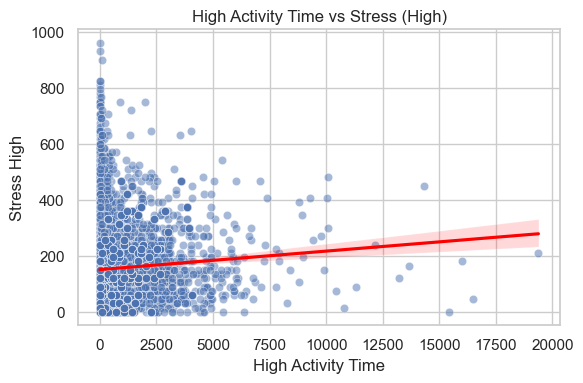

High Activity Time vs Stress (High): r = 0.062, p = 3.99e-07, n = 6766


In [146]:
# high_activity_time vs stress_high
scatter_and_corr(wide, 'high_activity_time', 'stress_high',
                 "High Activity Time vs Stress (High)")

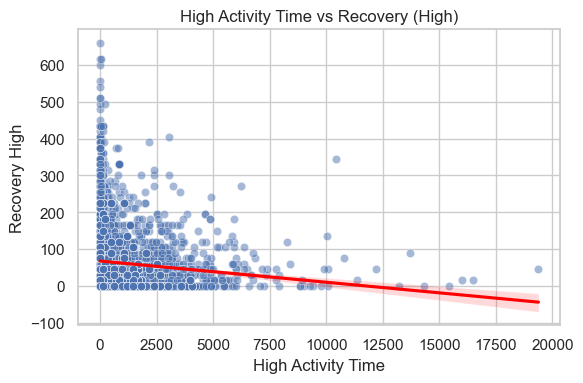

High Activity Time vs Recovery (High): r = -0.094, p = 8.53e-15, n = 6766


In [147]:
# high_activity_time vs recovery_high
scatter_and_corr(wide, 'high_activity_time', 'recovery_high',
                 "High Activity Time vs Recovery (High)")

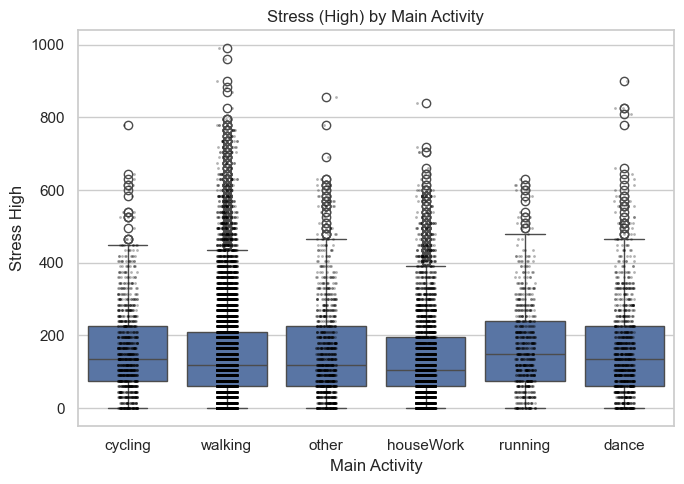

Stress (High) by Main Activity — ANOVA: F = 9.957, p = 1.58e-09, k = 6, n = 19916


In [148]:
# activity vs stress_high
# top N activities by count
N = 6
top_acts = (wide['main_activity'].value_counts()
            .head(N).index.tolist())
tmp = wide[wide['main_activity'].isin(top_acts)]
boxplot_and_anova(tmp, x_cat='main_activity', y_cont='stress_high',
                  title="Stress (High) by Main Activity")

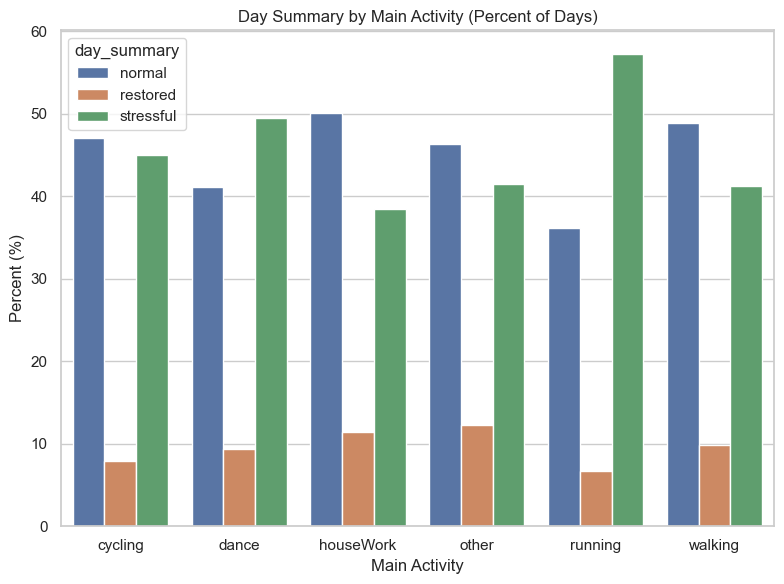

In [149]:
# activity vs day_summary
tmp = wide.dropna(subset=['main_activity','day_summary']).copy()
tmp = tmp[tmp['main_activity'].isin(top_acts)]

counts = (tmp.groupby(['main_activity','day_summary'])
             .size()
             .reset_index(name='n'))
counts['percent'] = counts['n'] / counts.groupby('main_activity')['n'].transform('sum') * 100

plt.figure(figsize=(8,6))
sns.barplot(data=counts, x='main_activity', y='percent', hue='day_summary')
plt.title("Day Summary by Main Activity (Percent of Days)")
plt.ylabel("Percent (%)")
plt.xlabel("Main Activity")
plt.tight_layout()
plt.show()

In [150]:
# Testing if trends change by menstrual phase

import pandas as pd
from scipy.stats import linregress
import statsmodels.api as sm
import statsmodels.formula.api as smf

PHASE_ORDER = ['menstrual','follicular','ovulation','luteal']

def phase_interaction_test(df, x, y, phase_col='phase', order=PHASE_ORDER):
    """
Tests if the relationship y ~ x changes by phase:
    OLS with interaction: y ~ x * C(phase)
    Prints ANOVA table (Type II) incl. interaction p
    Compares base vs full model to give ΔR² for the interaction
    Returns per-phase slopes, r, p, and n
    """
    # Prep
    cols = [x, y, phase_col]
    d = df[cols].dropna().copy()
    d = d[d[phase_col].isin(order)]
    if d.empty:
        print(f"[{y} ~ {x}] No data after filtering.")
        return None, None, None

    d[phase_col] = pd.Categorical(d[phase_col], categories=order, ordered=True)

    # Base vs Full models
    base = smf.ols(f'{y} ~ {x} + C({phase_col})', data=d).fit()
    full = smf.ols(f'{y} ~ {x} * C({phase_col})', data=d).fit()

    # ANOVA on full model (Type II) and model comparison for ΔRk^2
    anova_full = sm.stats.anova_lm(full, typ=2)
    cmp = sm.stats.anova_lm(base, full)

    # ΔR^2 contributed by the interaction term
    delta_r2 = full.rsquared - base.rsquared

    print("\n" + "="*72)
    print(f"{y} ~ {x} * phase   (n = {len(d)})")
    print("- Full-model ANOVA (Type II) -")
    # Show rows for x, phase main effect, and interaction
    for term in [x, f'C({phase_col})', f'{x}:C({phase_col})']:
        if term in anova_full.index:
            row = anova_full.loc[term]
            print(f"{term:>20s} :  F={row['F']:.3f}  p={row['PR(>F)']:.3g}")

    print("\n- Base vs Full model (ΔR² from interaction) -")
    print(cmp)  # includes F-test for adding the interaction
    print(f"\nΔR² (interaction added) = {delta_r2:.4f}")
    print(f"R² base={base.rsquared:.4f}  R² full={full.rsquared:.4f}")

    # Per-phase slopes & correlations
    rows = []
    for ph, g in d.groupby(phase_col):
        if len(g) >= 3:
            slope, intercept, r, p, se = linregress(g[x], g[y])
            rows.append([ph, len(g), slope, r, p])
    per_phase = pd.DataFrame(rows, columns=['phase','n','slope','r','p']).sort_values('phase')
    print("\nPer-phase slopes & correlations:")
    print(per_phase.to_string(index=False))

    return full, anova_full, per_phase

# Run tests on significant trends
# long/merged dataset is called `wide` and has columns: 'sleep_hours', 'total_calories', 'stress_high', 'resting_time', 'recovery_high', 'high_activity_time', and 'phase'

# Sleep vs Stress
phase_interaction_test(wide, x='sleep_hours', y='stress_high')

# Sleep vs Total Calories
phase_interaction_test(wide, x='sleep_hours', y='total_calories')

# Resting Time vs Recovery (High)
phase_interaction_test(wide, x='resting_time', y='recovery_high')

# High Activity Time vs Stress (High)
phase_interaction_test(wide, x='high_activity_time', y='stress_high')

# High Activity Time vs Recovery (High)
phase_interaction_test(wide, x='high_activity_time', y='recovery_high')


stress_high ~ sleep_hours * phase   (n = 2335)
- Full-model ANOVA (Type II) -
         sleep_hours :  F=16.970  p=3.93e-05
            C(phase) :  F=10.685  p=5.65e-07
sleep_hours:C(phase) :  F=1.747  p=0.155

- Base vs Full model (ΔR² from interaction) -
   df_resid           ssr  df_diff       ss_diff         F    Pr(>F)
0    2330.0  3.551995e+07      0.0           NaN       NaN       NaN
1    2327.0  3.544013e+07      3.0  79823.953525  1.747081  0.155278

ΔR² (interaction added) = 0.0022
R² base=0.0202  R² full=0.0224

Per-phase slopes & correlations:
     phase    n      slope         r        p
follicular 1144  -5.741697 -0.070791 0.016632
    luteal  739  -6.795984 -0.080830 0.028006
 menstrual  379  -9.088140 -0.092961 0.070653
 ovulation   73 -29.541234 -0.253286 0.030610

total_calories ~ sleep_hours * phase   (n = 2355)
- Full-model ANOVA (Type II) -
         sleep_hours :  F=10.200  p=0.00142
            C(phase) :  F=1.178  p=0.317
sleep_hours:C(phase) :  F=1.608  p=0.185

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/1369004987.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ph, g in d.groupby(phase_col):
/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/1369004987.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ph, g in d.groupby(phase_col):
/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/1369004987.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defaul

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1679faed0>,
                                    sum_sq      df          F        PR(>F)
 C(phase)                     5.573070e+05     3.0  34.712308  5.139453e-22
 high_activity_time           2.199977e+05     1.0  41.108201  1.688908e-10
 high_activity_time:C(phase)  3.721428e+04     3.0   2.317921  7.363057e-02
 Residual                     1.473851e+07  2754.0        NaN           NaN,
         phase     n     slope         r             p
 1  follicular  1250 -0.004783 -0.074898  8.070536e-03
 3      luteal  1010 -0.010287 -0.179517  9.203119e-09
 0   menstrual   410 -0.011401 -0.175576  3.541535e-04
 2   ovulation    92 -0.017976 -0.178572  8.854828e-02)

In [151]:
# Stress vs Total Calories
phase_interaction_test(wide, x='stress_high', y='total_calories')


total_calories ~ stress_high * phase   (n = 2762)
- Full-model ANOVA (Type II) -
         stress_high :  F=115.815  p=1.74e-26
            C(phase) :  F=1.113  p=0.342
stress_high:C(phase) :  F=2.148  p=0.0921

- Base vs Full model (ΔR² from interaction) -
   df_resid           ssr  df_diff        ss_diff         F    Pr(>F)
0    2757.0  4.211940e+08      0.0            NaN       NaN       NaN
1    2754.0  4.202108e+08      3.0  983278.643517  2.148088  0.092144

ΔR² (interaction added) = 0.0022
R² base=0.0405  R² full=0.0428

Per-phase slopes & correlations:
     phase    n    slope        r            p
follicular 1250 0.778815 0.232028 9.662290e-17
    luteal 1010 0.552355 0.174660 2.311679e-08
 menstrual  410 0.417194 0.146589 2.927759e-03
 ovulation   92 0.901860 0.336189 1.051226e-03


/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_5587/1369004987.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ph, g in d.groupby(phase_col):


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x313b27d50>,
                             sum_sq      df           F        PR(>F)
 C(phase)              5.094515e+05     3.0    1.112957  3.424636e-01
 stress_high           1.767122e+07     1.0  115.814598  1.741389e-26
 stress_high:C(phase)  9.832786e+05     3.0    2.148088  9.214381e-02
 Residual              4.202108e+08  2754.0         NaN           NaN,
         phase     n     slope         r             p
 1  follicular  1250  0.778815  0.232028  9.662290e-17
 3      luteal  1010  0.552355  0.174660  2.311679e-08
 0   menstrual   410  0.417194  0.146589  2.927759e-03
 2   ovulation    92  0.901860  0.336189  1.051226e-03)

New columns added to stress_phase: ['high_activity_time_x', 'high_activity_time_y', 'resting_time_x', 'resting_time_y', 'total_calories_x', 'total_calories_y']

Non-null counts after merge (available):
sleep_hours            3707
resting_time           6351
total_calories         6351
high_activity_time     6351
stress_high           51031
recovery_high         51031
phase                  2467
dtype: int64


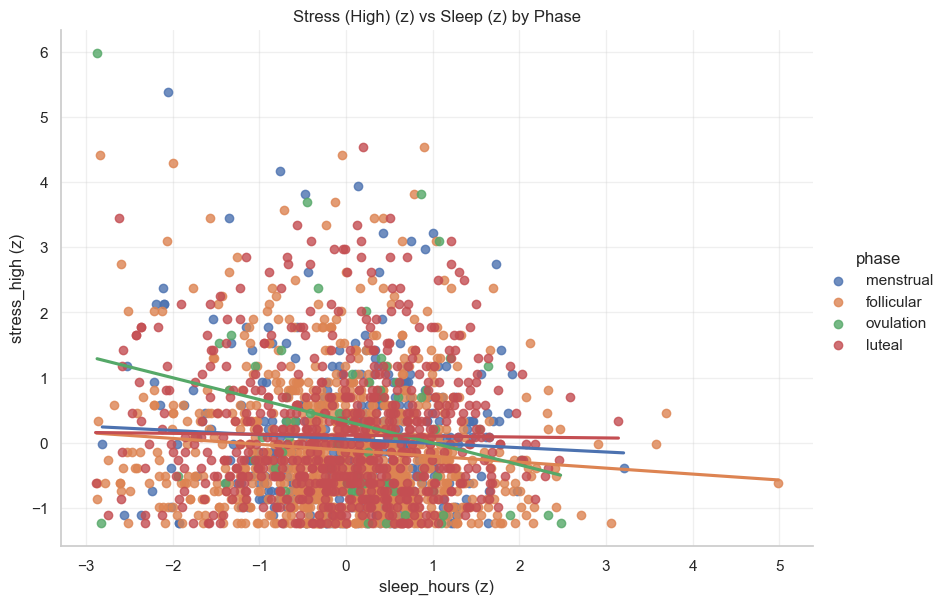

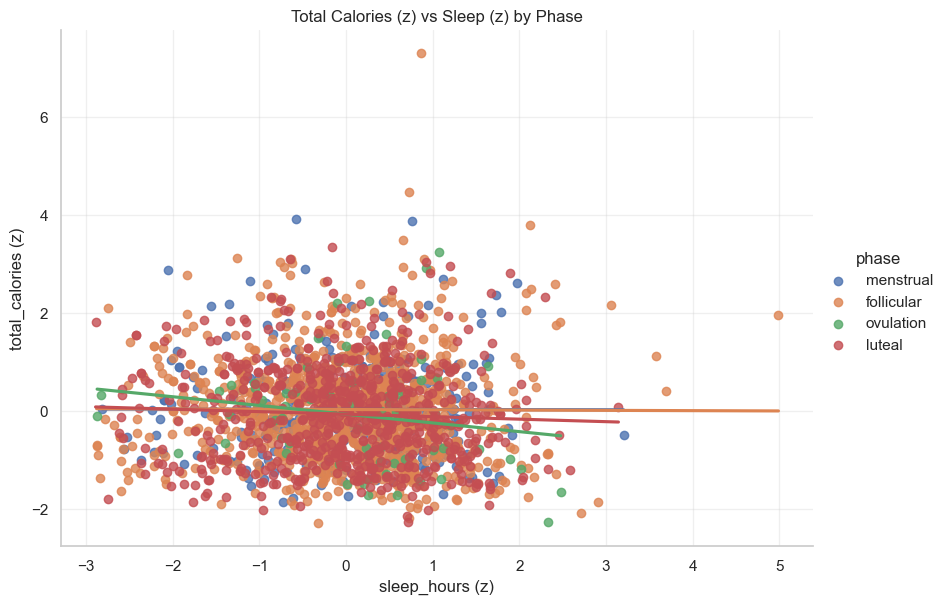

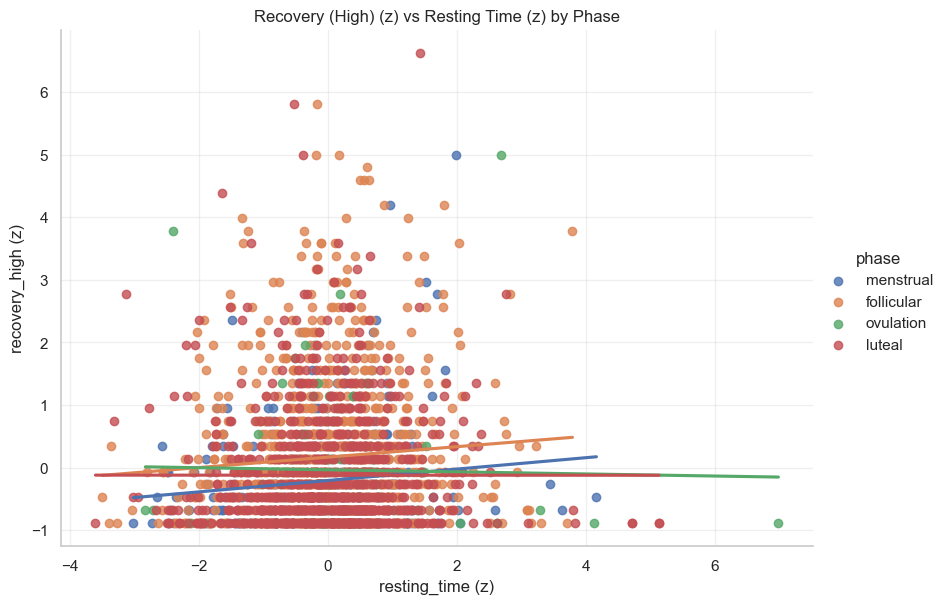

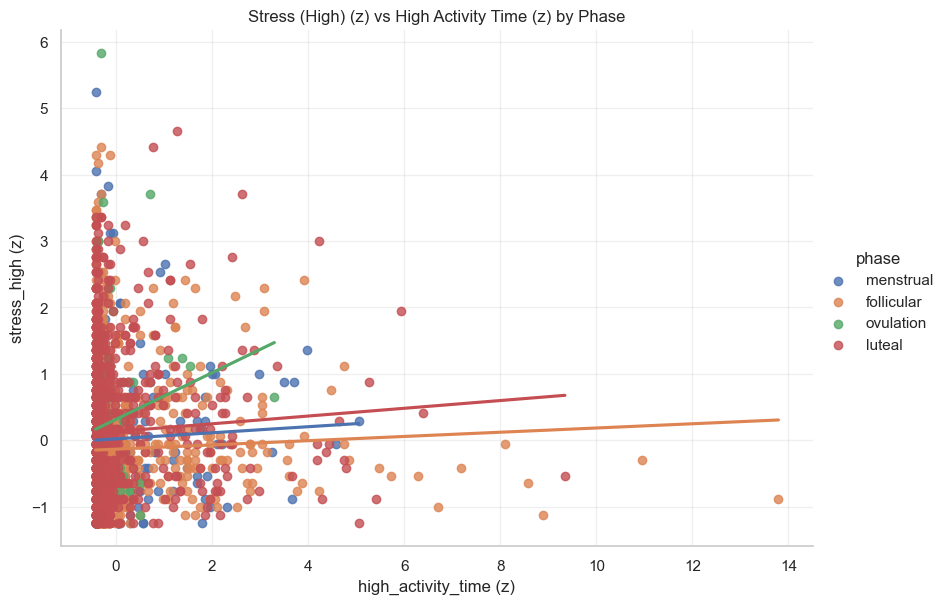

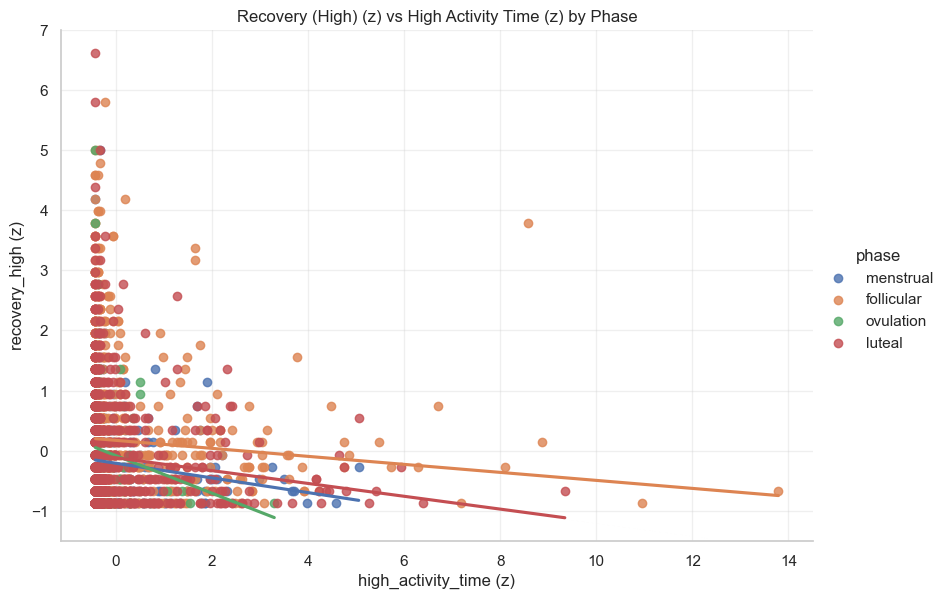

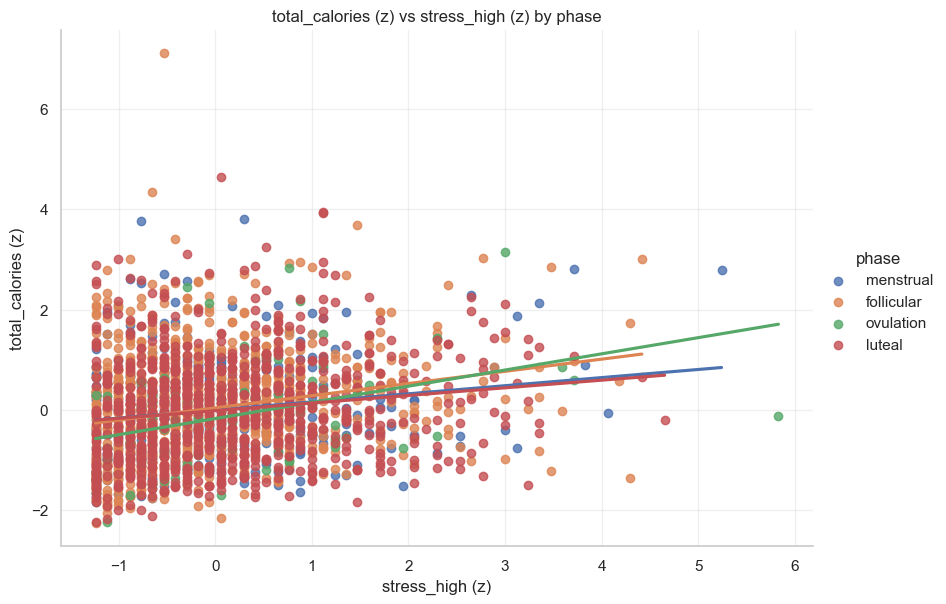

In [154]:
# merge, checks, plots
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

PHASE_ORDER = ['menstrual','follicular','ovulation','luteal']

# consistent column names and key dtypes
for _df in [df_activity, df_sleep, stress_phase]:
    _df.columns = _df.columns.str.strip()

# keys: day (date), name (int-ish)
df_activity['day']  = pd.to_datetime(df_activity['day'], errors='coerce').dt.date
df_sleep['day']     = pd.to_datetime(df_sleep['day'], errors='coerce').dt.date
stress_phase['day'] = pd.to_datetime(stress_phase['day'], errors='coerce').dt.date

df_activity['name']  = pd.to_numeric(df_activity['name'], errors='coerce').astype('Int64')
df_sleep['name']     = pd.to_numeric(df_sleep['name'], errors='coerce').astype('Int64')
stress_phase['name'] = pd.to_numeric(stress_phase['name'], errors='coerce').astype('Int64')

# stress_phase has sleep_hours
if 'sleep_hours' not in stress_phase.columns:
    if 'sleep_hours' in df_sleep.columns:
        # merge in sleep_hours
        stress_phase = stress_phase.merge(
            df_sleep[['day','name','sleep_hours']].drop_duplicates(['day','name']),
            on=['day','name'], how='left'
        )
    elif 'total_sleep_duration' in df_sleep.columns:
        # derive hours from seconds, then merge
        sleep_small = df_sleep[['day','name','total_sleep_duration']].copy()
        sleep_small['sleep_hours'] = pd.to_numeric(sleep_small['total_sleep_duration'], errors='coerce') / 3600.0
        stress_phase = stress_phase.merge(
            sleep_small[['day','name','sleep_hours']].drop_duplicates(['day','name']),
            on=['day','name'], how='left'
        )
    else:
        print("⚠️ Could not find sleep in df_sleep to add to stress_phase.")

# Merge activity cols we need (resting_time, total_calories, high_activity_time)
act_keep = ['day','name','resting_time','total_calories','high_activity_time']
missing_in_activity = [c for c in act_keep if c not in df_activity.columns]
if missing_in_activity:
    print("⚠️ Missing in df_activity:", missing_in_activity)

activity_small = df_activity[[c for c in act_keep if c in df_activity.columns]].drop_duplicates(['day','name'])

for col in ['resting_time','total_calories','high_activity_time']:
    if col in activity_small.columns:
        activity_small[col] = pd.to_numeric(activity_small[col], errors='coerce')

before_cols = set(stress_phase.columns)
stress_phase = stress_phase.merge(activity_small, on=['day','name'], how='left')
added_cols = sorted(list(set(stress_phase.columns) - before_cols))
print("New columns added to stress_phase:", added_cols)

# normalize suffixes back
for base in ['resting_time','total_calories','high_activity_time']:
    x, y = f"{base}_x", f"{base}_y"
    if x in stress_phase.columns and base not in stress_phase.columns:
        stress_phase.rename(columns={x: base}, inplace=True)
    if y in stress_phase.columns and base not in stress_phase.columns:
        stress_phase.rename(columns={y: base}, inplace=True)

# non-null counts for the variables plotted
want = ['sleep_hours','resting_time','total_calories','high_activity_time',
        'stress_high','recovery_high','phase']
have = [c for c in want if c in stress_phase.columns]
print("\nNon-null counts after merge (available):")
print(stress_phase[have].notna().sum())

# pooled z-scores and phase-colored OLS trend - helper
def zscore(s):
    s = pd.to_numeric(s, errors='coerce')
    return (s - s.mean()) / s.std(ddof=0)

def lm_by_phase_z(df, x, y, phase_col='phase', title=None, height=6, aspect=1.4):
    d = df[[phase_col, x, y]].copy()
    d = d.dropna(subset=[phase_col, x, y])
    d = d[d[phase_col].isin(PHASE_ORDER)]
    if d.empty:
        print(f"⚠️ No data for {title or f'{y} vs {x}'}"); 
        return
    # pooled z
    d['x_z'] = zscore(d[x])
    d['y_z'] = zscore(d[y])

    g = sns.lmplot(
        data=d, x='x_z', y='y_z', hue=phase_col, ci=None,
        height=height, aspect=aspect, hue_order=PHASE_ORDER
    )
    plt.title(title or f"{y} (z) vs {x} (z) by phase")
    plt.grid(True, alpha=0.3)
    plt.xlabel(f"{x} (z)")
    plt.ylabel(f"{y} (z)")
    plt.show()

# five core figures
titles = {
    ('sleep_hours','stress_high'):        "Stress (High) (z) vs Sleep (z) by Phase",
    ('sleep_hours','total_calories'):     "Total Calories (z) vs Sleep (z) by Phase",
    ('resting_time','recovery_high'):     "Recovery (High) (z) vs Resting Time (z) by Phase",
    ('high_activity_time','stress_high'): "Stress (High) (z) vs High Activity Time (z) by Phase",
    ('high_activity_time','recovery_high'):"Recovery (High) (z) vs High Activity Time (z) by Phase",
}

pairs = [
    ('sleep_hours','stress_high'),
    ('sleep_hours','total_calories'),
    ('resting_time','recovery_high'),
    ('high_activity_time','stress_high'),
    ('high_activity_time','recovery_high'),
    ('stress_high','total_calories'),
]

for x,y in pairs:
    missing = [c for c in [x,y,'phase'] if c not in stress_phase.columns]
    if missing:
        print(f"⚠️ Skipping {y} vs {x}: missing columns {missing}")
        continue
    lm_by_phase_z(stress_phase, x=x, y=y, title=titles.get((x,y)))

In [153]:
n_people = stress_phase['name'].nunique()
print("Unique participants:", n_people)

Unique participants: 267
